# Is Political Ideology a Better Indicator of Gun Ownership?
- As the title says, this is what I will be exploring in the file
- All the data in this file is found from [State Partisan Composition](https://www.ncsl.org/about-state-legislatures/state-partisan-composition)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
value_mapping = {
    'United States': 'US',
    'Alabama': 'AL',
    'Alaska': 'AK', 
    'Arizona': 'AZ', 
    'Arkansas': 'AR', 
    'California': 'CA',
    'Colorado': 'CO', 
    'Connecticut': 'CT', 
    'Delaware': 'DE', 
    'District of Columbia': 'DC',
    'Florida': 'FL',
    'Georgia': 'GA',
    'Hawaii': 'HI', 
    'Idaho': 'ID', 
    'Illinois': 'IL',
    'Indiana': 'IN', 
    'Iowa': 'IA', 
    'Kansas': 'KS',
    'Kentucky': 'KY',
    'Louisiana': 'LA',
    'Maine': 'ME',
    'Maryland': 'MD',
    'Massachusetts': 'MA',
    'Michigan': 'MI',
    'Minnesota': 'MN',
    'Mississippi': 'MS',
    'Missouri': 'MO',
    'Montana': 'MT',
    'Nebraska': 'NE',
    'Nevada': 'NV',
    'New Hampshire': 'NH',
    'New Jersey': 'NJ',
    'New Mexico': 'NM',
    'New York': 'NY',
    'North Carolina': 'NC',
    'North Dakota': 'ND',
    'Ohio': 'OH',
    'Oklahoma': 'OK',
    'Oregon': 'OR',
    'Pennsylvania': 'PA',
    'Puerto Rico': 'PR',
    'Rhode Island': 'RI', 
    'South Carolina': 'SC',
    'South Dakota': 'SD',
    'Tennessee': 'TN',
    'Texas': 'TX',
    'Utah': 'UT',
    'Vermont': 'VT',
    'Virginia': 'VA',
    'Washington': 'WA',
    'West Virginia': 'WV',
    'Wisconsin': 'WI',
    'Wyoming': 'WY'
}

### 2010
- The data from this table was taken from [State Partisan Composition Database](https://app.powerbi.com/view?r=eyJrIjoiZWQ5NDAwYzMtOWMwNC00ZDBkLTg3YzgtYjQxMGIxMDFmN2E4IiwidCI6IjM4MmZiOGIwLTRkYzMtNDEwNy04MGJkLTM1OTViMjQzMmZhZSIsImMiOjZ9)
- Instead of keeping all of the columns, I wanted to just look at the leaning of each state, so I calculated the leaning of the senate, leaning of the house, and then just averaged the two

In [3]:
pol2010 = pd.read_csv("../data/political/2010.csv")

In [4]:
pol2010.head()

pol2010["House Dem Rate"] = pol2010["House Dem"] / pol2010["Total House"]

In [5]:
pol2010["House Rep Rate"] = pol2010["House Rep"] / pol2010["Total House"]
pol2010["Senate Dem Rate"] = pol2010["Senate Dem"] / pol2010["Total Senate"]
pol2010["Senate Rep Rate"] = pol2010["Senate Rep"] / pol2010["Total Senate"]

In [6]:
pol2010.head()

,State,Total House,House Dem,House Rep,House Third Party,House Vacancies,Total Senate,Senate Dem,Senate Rep,Senate Third Party,Senate Vacancies,Legislative Control,Governor Party,State Control,House Dem Rate,House Rep Rate,Senate Dem Rate,Senate Rep Rate
0,Alabama,105.0,60.0,45.0,NaN,NaN,35,21.0,14.0,NaN,NaN,D,R,S,0.571429,0.428571,0.600000,0.400000
1,Alaska,40.0,18.0,22.0,NaN,NaN,20,10.0,10.0,NaN,NaN,S,R,S,0.450000,0.550000,0.500000,0.500000
2,Arizona,60.0,25.0,35.0,NaN,NaN,30,12.0,18.0,NaN,NaN,R,R,R,0.416667,0.583333,0.400000,0.600000
3,Arkansas,100.0,71.0,28.0,1.0,NaN,35,27.0,8.0,NaN,NaN,D,D,D,0.710000,0.280000,0.771429,0.228571
4,California,80.0,49.0,29.0,1.0,1.0,40,25.0,14.0,NaN,1.0,D,R,S,0.612500,0.362500,0.625000,0.350000


In [7]:
pol2010["House Leaning"] = pol2010["House Dem Rate"] - pol2010["House Rep Rate"]
pol2010["Senate Leaning"] = pol2010["Senate Dem Rate"] - pol2010["Senate Rep Rate"]

In [8]:
pol2010.head()

,State,Total House,House Dem,House Rep,House Third Party,House Vacancies,Total Senate,Senate Dem,Senate Rep,Senate Third Party,Senate Vacancies,Legislative Control,Governor Party,State Control,House Dem Rate,House Rep Rate,Senate Dem Rate,Senate Rep Rate,House Leaning,Senate Leaning
0,Alabama,105.0,60.0,45.0,NaN,NaN,35,21.0,14.0,NaN,NaN,D,R,S,0.571429,0.428571,0.600000,0.400000,0.142857,0.200000
1,Alaska,40.0,18.0,22.0,NaN,NaN,20,10.0,10.0,NaN,NaN,S,R,S,0.450000,0.550000,0.500000,0.500000,-0.100000,0.000000
2,Arizona,60.0,25.0,35.0,NaN,NaN,30,12.0,18.0,NaN,NaN,R,R,R,0.416667,0.583333,0.400000,0.600000,-0.166667,-0.200000
3,Arkansas,100.0,71.0,28.0,1.0,NaN,35,27.0,8.0,NaN,NaN,D,D,D,0.710000,0.280000,0.771429,0.228571,0.430000,0.542857
4,California,80.0,49.0,29.0,1.0,1.0,40,25.0,14.0,NaN,1.0,D,R,S,0.612500,0.362500,0.625000,0.350000,0.250000,0.275000


In [9]:
pol2010 = pol2010[["State", "House Leaning", "Senate Leaning"]]
pol2010["Average Leaning"] = (pol2010["House Leaning"] + pol2010["Senate Leaning"]) / 2

In [10]:
pol2010['State'] = pol2010['State'].replace(value_mapping) # Changing state names to abbreviations
pol2010['LocYear'] = pol2010['State'].astype(str) + '2010'
pol2010 = pol2010.drop(columns=["State"])

In [11]:
pol2010.head()

,House Leaning,Senate Leaning,Average Leaning,LocYear
0,0.142857,0.200000,0.171429,AL2010
1,-0.100000,0.000000,-0.050000,AK2010
2,-0.166667,-0.200000,-0.183333,AZ2010
3,0.430000,0.542857,0.486429,AR2010
4,0.250000,0.275000,0.262500,CA2010


In [12]:
# function to streamline the process

def pol_cleaning(df, state):
    df["House Dem Rate"] = df["House Dem"] / df["Total House"]
    df["House Rep Rate"] = df["House Rep"] / df["Total House"]
    df["Senate Dem Rate"] = df["Senate Dem"] / df["Total Senate"]
    df["Senate Rep Rate"] = df["Senate Rep"] / df["Total Senate"]

    df["House Leaning"] = df["House Dem Rate"] - df["House Rep Rate"]
    df["Senate Leaning"] = df["Senate Dem Rate"] - df["Senate Rep Rate"]

    df = df[["State", "House Leaning", "Senate Leaning"]]
    df["Average Leaning"] = (df["House Leaning"] + df["Senate Leaning"]) / 2

    df['State'] = df['State'].replace(value_mapping) # Changing state names to abbreviations
    df['LocYear'] = df['State'].astype(str) + state
    df = df.drop(columns=["State"])

    return df

### 2011
- The data from 2011 can be found through this link: [State Partisan Composition Database](https://app.powerbi.com/view?r=eyJrIjoiZWQ5NDAwYzMtOWMwNC00ZDBkLTg3YzgtYjQxMGIxMDFmN2E4IiwidCI6IjM4MmZiOGIwLTRkYzMtNDEwNy04MGJkLTM1OTViMjQzMmZhZSIsImMiOjZ9)

In [13]:
pol2011 = pd.read_csv("../data/political/2011.csv")
pol2011.head()

,State,Total House,House Dem,House Rep,House Third Party,House Vacancies,Total Senate,Senate Dem,Senate Rep,Senate Third Party,Senate Vacancies,Legislative Control,Governor Party,State Control
0,Alabama,105.0,39.0,66.0,NaN,NaN,35,12.0,22.0,1.0,NaN,R,R,R
1,Alaska,40.0,16.0,24.0,NaN,NaN,20,10.0,10.0,NaN,NaN,S,R,S
2,Arizona,60.0,20.0,40.0,NaN,NaN,30,9.0,21.0,NaN,NaN,R,R,R
3,Arkansas,100.0,55.0,44.0,NaN,1.0,35,20.0,15.0,NaN,NaN,D,D,D
4,California,80.0,52.0,28.0,NaN,NaN,40,25.0,15.0,NaN,NaN,D,D,D


In [14]:
pol2011 = pol_cleaning(pol2011, state='2011')

In [15]:
pol2011.head()

,House Leaning,Senate Leaning,Average Leaning,LocYear
0,-0.257143,-0.285714,-0.271429,AL2011
1,-0.200000,0.000000,-0.100000,AK2011
2,-0.333333,-0.400000,-0.366667,AZ2011
3,0.110000,0.142857,0.126429,AR2011
4,0.300000,0.250000,0.275000,CA2011


### 2012
- The data from this section was found from [State Partisan Composition Database](https://app.powerbi.com/view?r=eyJrIjoiZWQ5NDAwYzMtOWMwNC00ZDBkLTg3YzgtYjQxMGIxMDFmN2E4IiwidCI6IjM4MmZiOGIwLTRkYzMtNDEwNy04MGJkLTM1OTViMjQzMmZhZSIsImMiOjZ9)

In [16]:
pol2012 = pd.read_csv("../data/political/2012.csv")
pol2012.head()

,State,Total House,House Dem,House Rep,House Third Party,House Vacancies,Total Senate,Senate Dem,Senate Rep,Senate Third Party,Senate Vacancies,Legislative Control,Governor Party,State Control
0,Alabama,105.0,40.0,65.0,NaN,NaN,35,12.0,22.0,1.0,NaN,R,R,R
1,Alaska,40.0,18.0,22.0,NaN,NaN,20,10.0,10.0,NaN,NaN,S,R,S
2,Arizona,60.0,20.0,40.0,NaN,NaN,30,9.0,21.0,NaN,NaN,R,R,R
3,Arkansas,100.0,55.0,45.0,NaN,NaN,35,20.0,15.0,NaN,NaN,D,D,D
4,California,80.0,52.0,28.0,NaN,NaN,40,25.0,15.0,NaN,NaN,D,D,D


In [17]:
pol2012 = pol_cleaning(pol2012, state='2012')
pol2012.head()

,House Leaning,Senate Leaning,Average Leaning,LocYear
0,-0.238095,-0.285714,-0.261905,AL2012
1,-0.100000,0.000000,-0.050000,AK2012
2,-0.333333,-0.400000,-0.366667,AZ2012
3,0.100000,0.142857,0.121429,AR2012
4,0.300000,0.250000,0.275000,CA2012


### 2013
- The data from this section was found from [State Partisan Composition Database](https://app.powerbi.com/view?r=eyJrIjoiZWQ5NDAwYzMtOWMwNC00ZDBkLTg3YzgtYjQxMGIxMDFmN2E4IiwidCI6IjM4MmZiOGIwLTRkYzMtNDEwNy04MGJkLTM1OTViMjQzMmZhZSIsImMiOjZ9)

In [18]:
pol2013 = pd.read_csv("../data/political/2013.csv")
pol2013.head()

,State,Total House,House Dem,House Rep,House Third Party,House Vacancies,Total Senate,Senate Dem,Senate Rep,Senate Third Party,Senate Vacancies,Legislative Control,Governor Party,State Control
0,Alabama,105.0,39.0,64.0,NaN,2.0,35,11.0,23.0,1.0,NaN,R,R,R
1,Alaska,40.0,15.0,25.0,NaN,NaN,20,7.0,13.0,NaN,NaN,R,R,R
2,Arizona,60.0,24.0,36.0,NaN,NaN,30,13.0,17.0,NaN,NaN,R,R,R
3,Arkansas,100.0,48.0,51.0,1.0,NaN,35,14.0,21.0,NaN,NaN,R,D,S
4,California,80.0,54.0,26.0,NaN,NaN,40,26.0,12.0,NaN,2.0,D,D,D


In [19]:
pol2013 = pol_cleaning(pol2013, state='2013')
pol2013.head()

,House Leaning,Senate Leaning,Average Leaning,LocYear
0,-0.238095,-0.342857,-0.290476,AL2013
1,-0.250000,-0.300000,-0.275000,AK2013
2,-0.200000,-0.133333,-0.166667,AZ2013
3,-0.030000,-0.200000,-0.115000,AR2013
4,0.350000,0.350000,0.350000,CA2013


### 2014
- The data from this section was found from [State Partisan Composition Database](https://app.powerbi.com/view?r=eyJrIjoiZWQ5NDAwYzMtOWMwNC00ZDBkLTg3YzgtYjQxMGIxMDFmN2E4IiwidCI6IjM4MmZiOGIwLTRkYzMtNDEwNy04MGJkLTM1OTViMjQzMmZhZSIsImMiOjZ9)

In [20]:
pol2014 = pd.read_csv("../data/political/2014.csv")
pol2014.head()

,State,Total House,House Dem,House Rep,House Third Party,House Vacancies,Total Senate,Senate Dem,Senate Rep,Senate Third Party,Senate Vacancies,Legislative Control,Governor Party,State Control
0,Alabama,105.0,37.0,63.0,1.0,4.0,35,11.0,23.0,1.0,NaN,R,R,R
1,Alaska,40.0,13.0,26.0,NaN,1.0,20,7.0,13.0,NaN,NaN,R,R,R
2,Arizona,60.0,24.0,36.0,NaN,NaN,30,12.0,17.0,NaN,1.0,R,R,R
3,Arkansas,100.0,48.0,51.0,1.0,NaN,35,13.0,22.0,NaN,NaN,R,D,S
4,California,80.0,55.0,25.0,NaN,NaN,40,28.0,11.0,NaN,1.0,D,D,D


In [21]:
pol2014 = pol_cleaning(pol2014, state='2014')
pol2014.head()

,House Leaning,Senate Leaning,Average Leaning,LocYear
0,-0.247619,-0.342857,-0.295238,AL2014
1,-0.325000,-0.300000,-0.312500,AK2014
2,-0.200000,-0.166667,-0.183333,AZ2014
3,-0.030000,-0.257143,-0.143571,AR2014
4,0.375000,0.425000,0.400000,CA2014


### 2015
- The data from this section was found from [State Partisan Composition Database](https://app.powerbi.com/view?r=eyJrIjoiZWQ5NDAwYzMtOWMwNC00ZDBkLTg3YzgtYjQxMGIxMDFmN2E4IiwidCI6IjM4MmZiOGIwLTRkYzMtNDEwNy04MGJkLTM1OTViMjQzMmZhZSIsImMiOjZ9)

In [22]:
pol2015 = pd.read_csv("../data/political/2015.csv")
pol2015.head()

,State,Total House,House Dem,House Rep,House Third Party,House Vacancies,Total Senate,Senate Dem,Senate Rep,Senate Third Party,Senate Vacancies,Legislative Control,Governor Party,State Control
0,Alabama,105.0,33.0,72.0,NaN,NaN,35,8.0,26.0,1.0,NaN,R,R,R
1,Alaska,40.0,16.0,23.0,1.0,NaN,20,6.0,14.0,NaN,NaN,R,I,S
2,Arizona,60.0,24.0,36.0,NaN,NaN,30,13.0,17.0,NaN,NaN,R,R,R
3,Arkansas,100.0,36.0,64.0,NaN,NaN,35,11.0,24.0,NaN,NaN,R,R,R
4,California,80.0,52.0,28.0,NaN,NaN,40,25.0,12.0,NaN,3.0,D,D,D


In [23]:
pol2015 = pol_cleaning(pol2015, state='2015')
pol2015.head()

,House Leaning,Senate Leaning,Average Leaning,LocYear
0,-0.371429,-0.514286,-0.442857,AL2015
1,-0.175000,-0.400000,-0.287500,AK2015
2,-0.200000,-0.133333,-0.166667,AZ2015
3,-0.280000,-0.371429,-0.325714,AR2015
4,0.300000,0.325000,0.312500,CA2015


### 2016
- The data from this section was found from [State Partisan Composition Database](https://app.powerbi.com/view?r=eyJrIjoiZWQ5NDAwYzMtOWMwNC00ZDBkLTg3YzgtYjQxMGIxMDFmN2E4IiwidCI6IjM4MmZiOGIwLTRkYzMtNDEwNy04MGJkLTM1OTViMjQzMmZhZSIsImMiOjZ9)

In [24]:
pol2016 = pd.read_csv("../data/political/2016.csv")
pol2016.head()

,State,Total House,House Dem,House Rep,House Third Party,House Vacancies,Total Senate,Senate Dem,Senate Rep,Senate Third Party,Senate Vacancies,Legislative Control,Governor Party,State Control
0,Alabama,105.0,33.0,72.0,NaN,NaN,35,8.0,26.0,1.0,NaN,R,R,R
1,Alaska,40.0,16.0,23.0,1.0,NaN,20,6.0,14.0,NaN,NaN,R,I,S
2,Arizona,60.0,24.0,36.0,NaN,NaN,30,13.0,17.0,NaN,NaN,R,R,R
3,Arkansas,100.0,36.0,64.0,NaN,NaN,35,11.0,24.0,NaN,NaN,R,R,R
4,California,80.0,52.0,28.0,NaN,NaN,40,25.0,14.0,NaN,1.0,D,D,D


In [25]:
pol2016 = pol_cleaning(pol2016, state='2016')
pol2016.head()

,House Leaning,Senate Leaning,Average Leaning,LocYear
0,-0.371429,-0.514286,-0.442857,AL2016
1,-0.175000,-0.400000,-0.287500,AK2016
2,-0.200000,-0.133333,-0.166667,AZ2016
3,-0.280000,-0.371429,-0.325714,AR2016
4,0.300000,0.275000,0.287500,CA2016


## Combining Data

In [26]:
pol_df = pd.concat([pol2010, pol2011, pol2012, pol2013, pol2014, pol2015, pol2016], ignore_index=True)

In [27]:
pol_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   House Leaning    343 non-null    float64
 1   Senate Leaning   343 non-null    float64
 2   Average Leaning  343 non-null    float64
 3   LocYear          350 non-null    str    
dtypes: float64(3), str(1)
memory usage: 13.1 KB


should i just drop the missing values..?

In [28]:
pol_df[pol_df.isnull().any(axis=1)]

,House Leaning,Senate Leaning,Average Leaning,LocYear
26,NaN,NaN,NaN,NE2010
76,NaN,NaN,NaN,NE2011
126,NaN,NaN,NaN,NE2012
176,NaN,NaN,NaN,NE2013
226,NaN,NaN,NaN,NE2014
276,NaN,NaN,NaN,NE2015
326,NaN,NaN,NaN,NE2016


okay since it is all Nebraska I think I am just going to drop it

In [29]:
pol_df = pol_df.dropna()

In [30]:
pol_df.info()

<class 'pandas.DataFrame'>
Index: 343 entries, 0 to 349
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   House Leaning    343 non-null    float64
 1   Senate Leaning   343 non-null    float64
 2   Average Leaning  343 non-null    float64
 3   LocYear          343 non-null    str    
dtypes: float64(3), str(1)
memory usage: 15.5 KB


## The Analysis
- Now, I am going to get the original dataset that I made and perform a similar analysis

In [31]:
df = pd.read_csv("../data/FINAL_DF.csv")

In [32]:
df.head()

,Geography,LocYear,% >= HS,% >= Bachelor's,"Pov for 25yo<=, <HS","Pov for 25<=, >=Bachelor's",GeoFIPS,HFR,SNAP_rate,DPI_rate,PI_rate
0,0400000US01,AL2010,0.821,0.219,0.300,0.041,1000,0.456,0.147621,0.082011,0.089287
1,0400000US02,AK2010,0.910,0.279,0.177,0.028,2000,0.611,0.132925,0.128447,0.138935
2,0400000US04,AZ2010,0.856,0.259,0.301,0.046,4000,0.346,0.139955,0.085180,0.092639
3,0400000US05,AR2010,0.829,0.195,0.267,0.039,5000,0.493,0.142676,0.077484,0.084426
4,0400000US06,CA2010,0.807,0.301,0.253,0.049,6000,0.174,0.087893,0.115410,0.129771


In [33]:
full_df = pd.merge(pol_df, df, on="LocYear")

In [34]:
full_df.head()

,House Leaning,Senate Leaning,Average Leaning,LocYear,Geography,% >= HS,% >= Bachelor's,"Pov for 25yo<=, <HS","Pov for 25<=, >=Bachelor's",GeoFIPS,HFR,SNAP_rate,DPI_rate,PI_rate
0,0.142857,0.200000,0.171429,AL2010,0400000US01,0.821,0.219,0.300,0.041,1000,0.456,0.147621,0.082011,0.089287
1,-0.100000,0.000000,-0.050000,AK2010,0400000US02,0.910,0.279,0.177,0.028,2000,0.611,0.132925,0.128447,0.138935
2,-0.166667,-0.200000,-0.183333,AZ2010,0400000US04,0.856,0.259,0.301,0.046,4000,0.346,0.139955,0.085180,0.092639
3,0.430000,0.542857,0.486429,AR2010,0400000US05,0.829,0.195,0.267,0.039,5000,0.493,0.142676,0.077484,0.084426
4,0.250000,0.275000,0.262500,CA2010,0400000US06,0.807,0.301,0.253,0.049,6000,0.174,0.087893,0.115410,0.129771


In [35]:
full_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 343 entries, 0 to 342
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   House Leaning               343 non-null    float64
 1   Senate Leaning              343 non-null    float64
 2   Average Leaning             343 non-null    float64
 3   LocYear                     343 non-null    str    
 4   Geography                   343 non-null    str    
 5   % >= HS                     343 non-null    float64
 6   % >= Bachelor's             343 non-null    float64
 7   Pov for 25yo<=, <HS         343 non-null    float64
 8   Pov for 25<=, >=Bachelor's  343 non-null    float64
 9   GeoFIPS                     343 non-null    int64  
 10  HFR                         343 non-null    float64
 11  SNAP_rate                   343 non-null    float64
 12  DPI_rate                    343 non-null    float64
 13  PI_rate                     343 non-null    fl

In [36]:
full_df.to_csv('../data/POL_FINAL_DF.csv', index=False)

### Some EDA

In [37]:
X = full_df[["House Leaning", "Senate Leaning", "Average Leaning", "% >= HS", "% >= Bachelor's", "PI_rate"]]

In [38]:
y = full_df["HFR"]

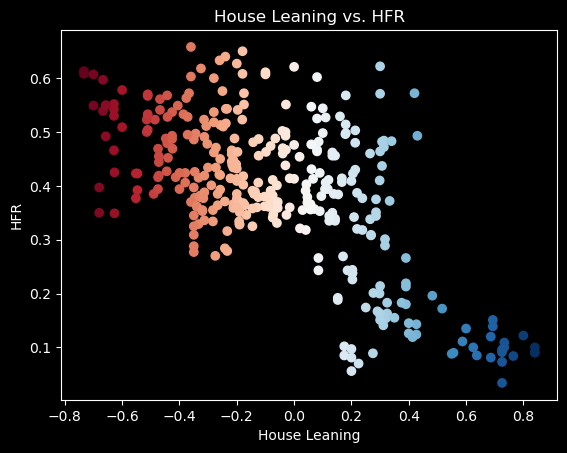

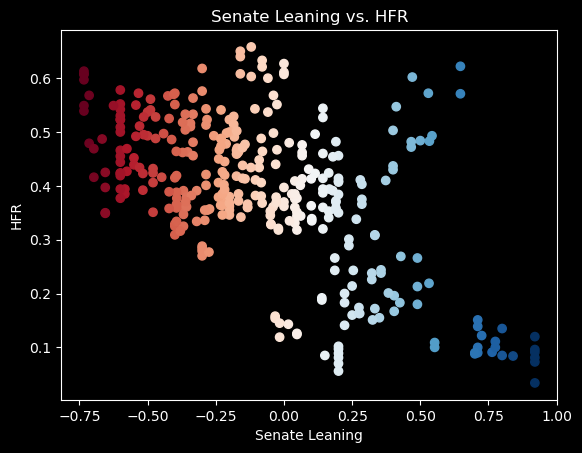

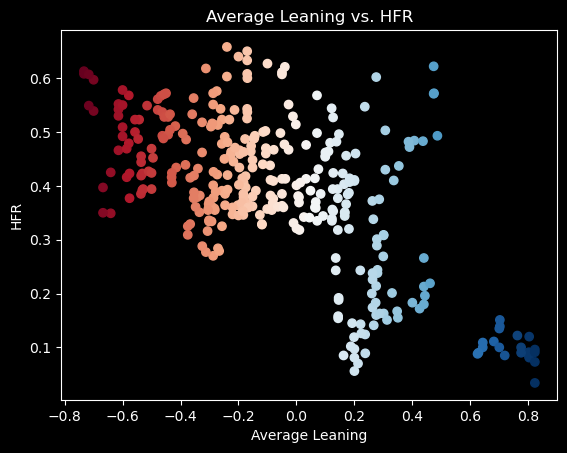

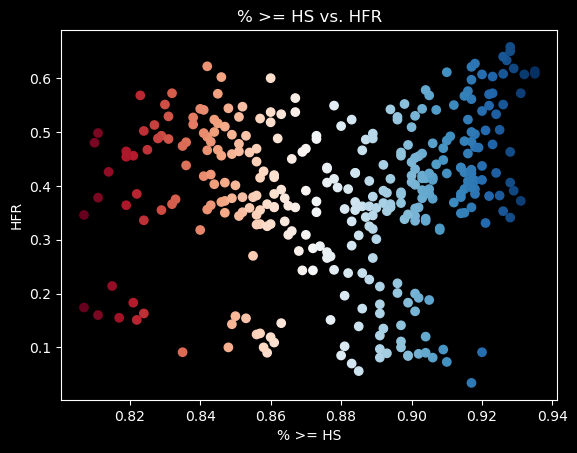

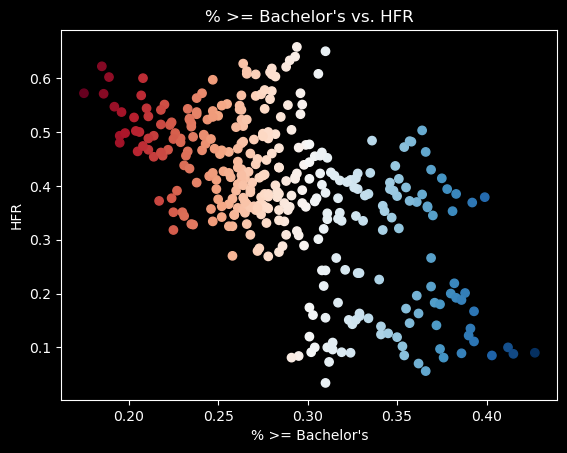

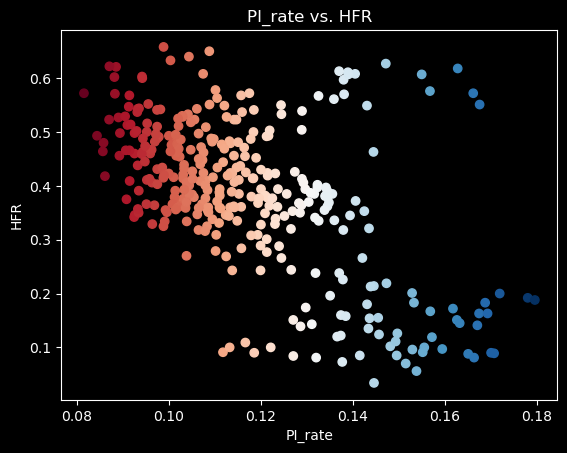

In [39]:
def make_scatterplots(X, y):
    for col_name in X:
        col = X[col_name]
        plt.style.use('dark_background')
        plt.scatter(col, y, c=col, cmap='RdBu')
        plt.xlabel(col_name)
        plt.ylabel("HFR")
        plt.title(col_name + " vs. HFR")
        plt.show()

make_scatterplots(X, y)

                 House Leaning  Senate Leaning  Average Leaning   % >= HS  \
House Leaning         1.000000        0.903924         0.972960 -0.153258   
Senate Leaning        0.903924        1.000000         0.978268 -0.055692   
Average Leaning       0.972960        0.978268         1.000000 -0.104376   
% >= HS              -0.153258       -0.055692        -0.104376  1.000000   
% >= Bachelor's       0.351313        0.406996         0.390113  0.483141   
PI_rate               0.265069        0.283730         0.281732  0.322221   
HFR                  -0.655017       -0.585684        -0.633848  0.098192   

                 % >= Bachelor's   PI_rate       HFR  
House Leaning           0.351313  0.265069 -0.655017  
Senate Leaning          0.406996  0.283730 -0.585684  
Average Leaning         0.390113  0.281732 -0.633848  
% >= HS                 0.483141  0.322221  0.098192  
% >= Bachelor's         1.000000  0.729096 -0.591182  
PI_rate                 0.729096  1.000000 -0.554006 

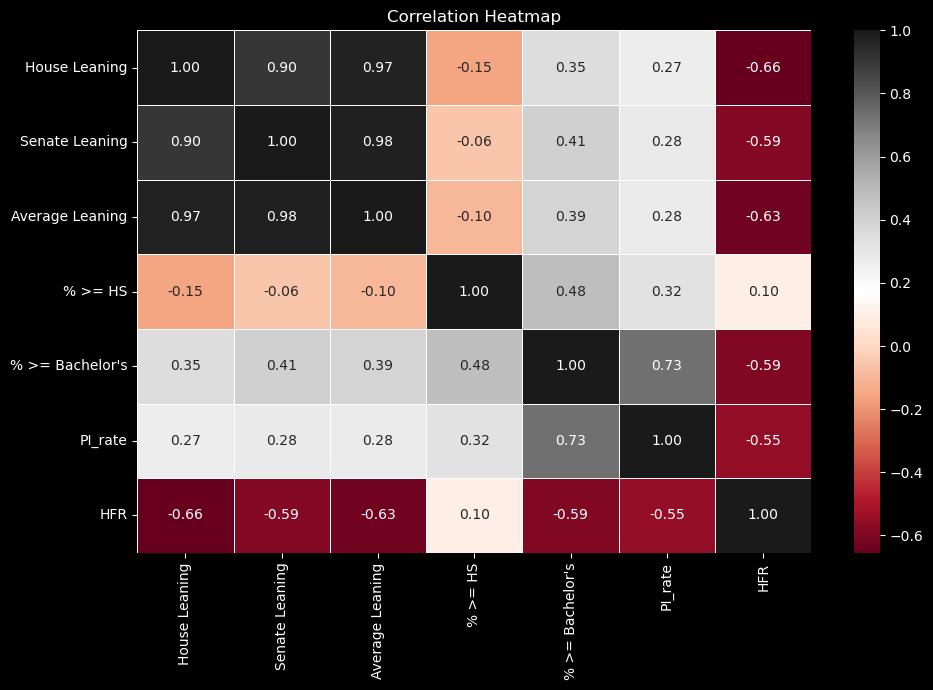

In [40]:
new_df = full_df[["House Leaning", "Senate Leaning", 
                  "Average Leaning", "% >= HS", "% >= Bachelor's", "PI_rate", "HFR"]]
def make_heatmap(x, cmap='RdGy', title="Correlation Heatmap"):
    matrix = x.corr()
    print(matrix)
    plt.figure(figsize=(10,7))
    sns.heatmap(matrix, annot=True, cmap=cmap, fmt=".2f", linewidths=0.5)
    plt.title(title)
    plt.tight_layout()
    plt.show()

make_heatmap(new_df)

## Feature Importance

In [41]:
import numpy as np
from sklearn.linear_model import LinearRegression

### Linear Regression

In [42]:
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
r_sq = model.score(X, y)
print(f"coefficient of determination: {r_sq}")

importance_df1 = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(model.coef_)
}).sort_values(by='Importance', ascending=False)

print(importance_df1)

coefficient of determination: 0.6823855706214048
           Feature  Importance
5          PI_rate    1.535199
3          % >= HS    1.419124
4  % >= Bachelor's    1.286085
0    House Leaning    0.193196
1   Senate Leaning    0.088460
2  Average Leaning    0.052368


In [44]:
new_X = full_df[["House Leaning", "% >= HS", "% >= Bachelor's", "PI_rate"]]

In [45]:
model = LinearRegression()
model.fit(new_X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [46]:
r_sq = model.score(new_X, y)
print(f"coefficient of determination: {r_sq}")

importance_df2 = pd.DataFrame({
    'Feature': new_X.columns,
    'Importance': abs(model.coef_)
}).sort_values(by='Importance', ascending=False)

print(importance_df2)

coefficient of determination: 0.6774336231643214
           Feature  Importance
3          PI_rate    1.583378
1          % >= HS    1.450300
2  % >= Bachelor's    1.235457
0    House Leaning    0.158066


### Single LR

In [47]:
def r2_scores(X, y):
    r2_dict = dict()
    for col_name in X:
        X2 = X[[col_name]]
        model = LinearRegression()
        model.fit(X2, y)
        r_sq = model.score(X2, y)
        r2_dict[col_name] = r_sq
        r_sq = None
    return r2_dict

In [48]:
single_scores = r2_scores(X, y)

In [49]:
single_scores

{'House Leaning': 0.429046649109489,
 'Senate Leaning': 0.34302623722696524,
 'Average Leaning': 0.401763618606056,
 '% >= HS': 0.009641643993128723,
 "% >= Bachelor's": 0.3494962269173397,
 'PI_rate': 0.30692263561071786}

In [50]:
single_lr = pd.DataFrame(list(single_scores.items()), columns=['Feature', 'SingleLinearReg'])
single_lr

,Feature,SingleLinearReg
0,House Leaning,0.429047
1,Senate Leaning,0.343026
2,Average Leaning,0.401764
3,% >= HS,0.009642
4,% >= Bachelor's,0.349496
5,PI_rate,0.306923


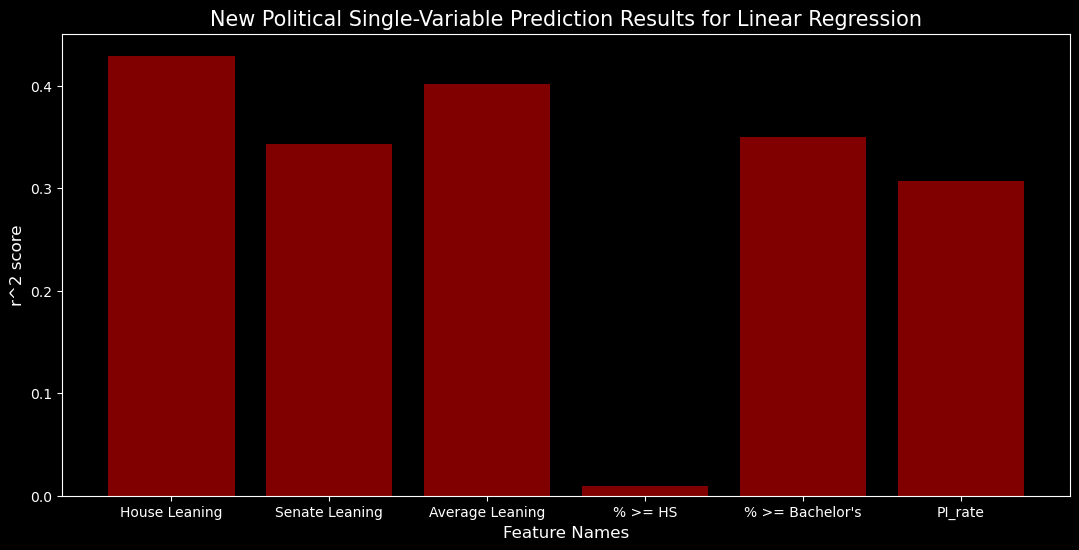

In [51]:
plt.figure(figsize=(13, 6))
plt.bar(single_scores.keys(), single_scores.values(), color="maroon")
plt.xlabel("Feature Names", fontsize=12)
plt.ylabel("r^2 score", fontsize=12)
plt.xticks(fontsize=10)
plt.title("New Political Single-Variable Prediction Results for Linear Regression", fontsize=15)
plt.show()

## Permutation Feature Importance

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42)

rf = RandomForestRegressor(random_state=42).fit(X_train, y_train)
print(f"Model Score: {rf.score(X_test, y_test)}")

r = permutation_importance(rf, X_test, y_test,
                           n_repeats=30,
                           random_state=0, scoring='r2')

column_names_list = X.columns.tolist()

for i in r.importances_mean.argsort()[::-1]:
    print(f"{column_names_list[i]:<8}" + ': '
            f"{r.importances_mean[i]:.3f}"
            f" +/- {r.importances_std[i]:.3f}")
    
feature_importance_df1 = pd.DataFrame({'Feature': column_names_list, 'Permutation': r.importances_mean})    
print("Feature importance:\n", feature_importance_df1)
feature_importance_df1

Model Score: 0.8408113445541923
House Leaning: 0.407 +/- 0.057
PI_rate : 0.283 +/- 0.055
% >= Bachelor's: 0.200 +/- 0.037
% >= HS : 0.134 +/- 0.024
Average Leaning: 0.057 +/- 0.010
Senate Leaning: 0.021 +/- 0.004
Feature importance:
            Feature  Permutation
0    House Leaning     0.406944
1   Senate Leaning     0.021484
2  Average Leaning     0.057141
3          % >= HS     0.133795
4  % >= Bachelor's     0.200450
5          PI_rate     0.283051


,Feature,Permutation
0,House Leaning,0.406944
1,Senate Leaning,0.021484
2,Average Leaning,0.057141
3,% >= HS,0.133795
4,% >= Bachelor's,0.200450
5,PI_rate,0.283051


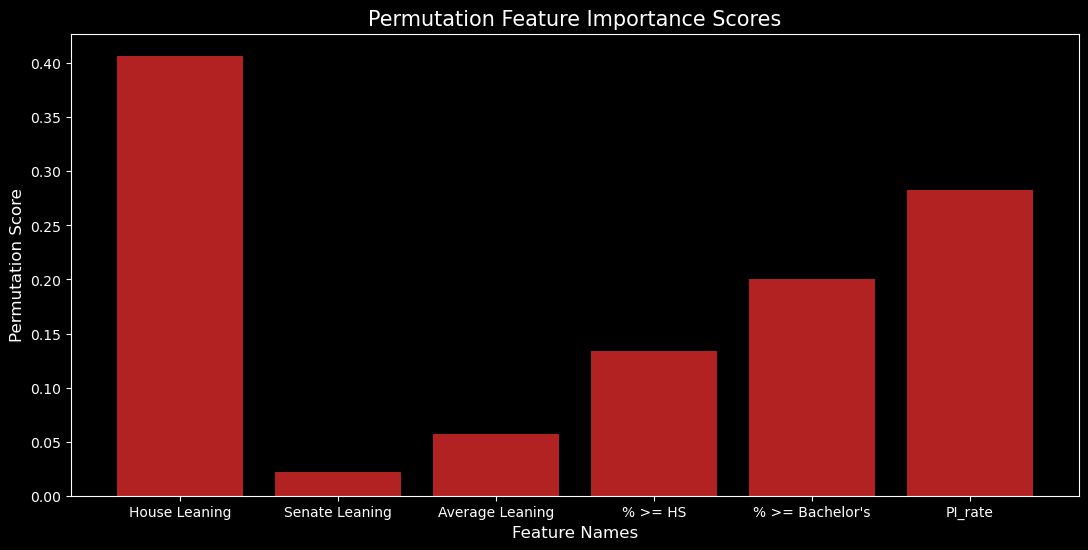

In [54]:
plt.figure(figsize=(13, 6))
plt.bar(feature_importance_df1["Feature"], feature_importance_df1["Permutation"], color="firebrick")
plt.xlabel("Feature Names", fontsize=12)
plt.ylabel("Permutation Score", fontsize=12)
plt.xticks(fontsize=10)
plt.title("Permutation Feature Importance Scores", fontsize=15)
plt.show()

Running it again with just House Leaning

In [55]:
new_X = full_df[["House Leaning", "% >= HS", "% >= Bachelor's", "PI_rate"]]

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    new_X, y, random_state=42)

rf = RandomForestRegressor(random_state=42).fit(X_train, y_train)
print(f"Model Score: {rf.score(X_test, y_test)}")

r = permutation_importance(rf, X_test, y_test,
                           n_repeats=30,
                           random_state=0, scoring='r2')

column_names_list = new_X.columns.tolist()

for i in r.importances_mean.argsort()[::-1]:
    print(f"{column_names_list[i]:<8}" + ': '
            f"{r.importances_mean[i]:.3f}"
            f" +/- {r.importances_std[i]:.3f}")
    
feature_importance_df2 = pd.DataFrame({'Feature': column_names_list, 'Permutation': r.importances_mean})    
print("Feature importance:\n", feature_importance_df2)
feature_importance_df2

Model Score: 0.8285763231908111
House Leaning: 0.721 +/- 0.088
PI_rate : 0.307 +/- 0.057
% >= Bachelor's: 0.232 +/- 0.041
% >= HS : 0.137 +/- 0.027
Feature importance:
            Feature  Permutation
0    House Leaning     0.721278
1          % >= HS     0.137299
2  % >= Bachelor's     0.232271
3          PI_rate     0.306740


,Feature,Permutation
0,House Leaning,0.721278
1,% >= HS,0.137299
2,% >= Bachelor's,0.232271
3,PI_rate,0.306740


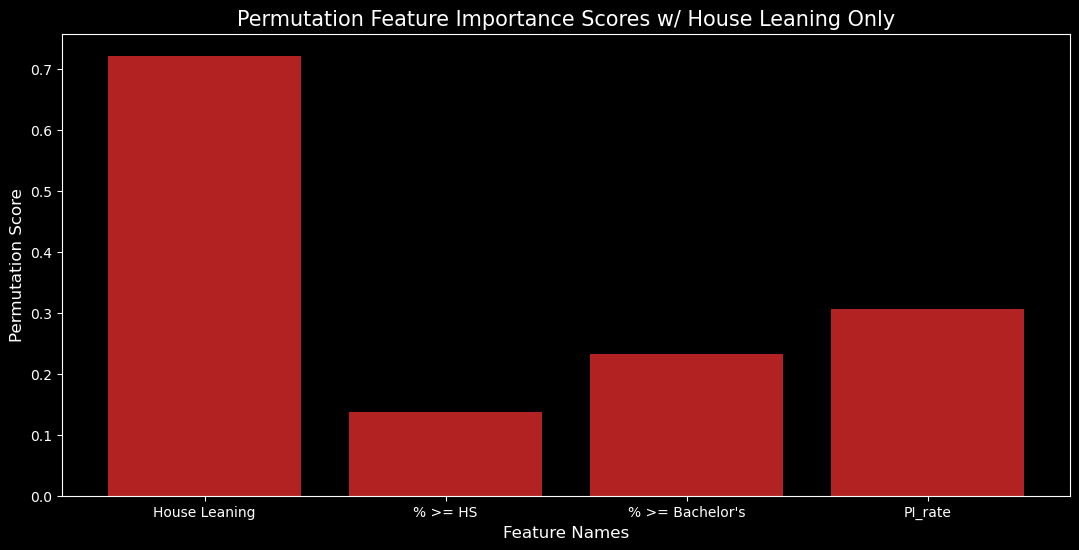

In [57]:
plt.figure(figsize=(13, 6))
plt.bar(feature_importance_df2["Feature"], feature_importance_df2["Permutation"], color="firebrick")
plt.xlabel("Feature Names", fontsize=12)
plt.ylabel("Permutation Score", fontsize=12)
plt.xticks(fontsize=10)
plt.title("Permutation Feature Importance Scores w/ House Leaning Only", fontsize=15)
plt.show()

## Random Forest

In [58]:
X = full_df[["House Leaning", "Senate Leaning", "Average Leaning", "% >= HS", "% >= Bachelor's", "PI_rate"]]

y = full_df["HFR"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42)

In [59]:
rf = RandomForestRegressor(bootstrap=False, max_depth=10, max_features=0.7,
                      min_samples_leaf=10,
                      min_samples_split=20,
                      n_estimators=np.int64(1136))
rf.fit(X_train, y_train)

# scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
# print(f"Mean r^2 score accross 5 folds for {rf}: {np.mean(scores):.3f}")
# print(f"All fold scores for {rf}: {scores}\n")

rf.fit(X_train, y_train)
print(rf.score(X_test, y_test))

column_names_list = X.columns.tolist()

importance = rf.feature_importances_
D = dict()
for i, v in enumerate(importance):
    D[column_names_list[i]] = v
    print(f'{column_names_list[i]}, Score: {v:.5f}')

0.7668715244294135
House Leaning, Score: 0.39018
Senate Leaning, Score: 0.01963
Average Leaning, Score: 0.14493
% >= HS, Score: 0.08455
% >= Bachelor's, Score: 0.14398
PI_rate, Score: 0.21674


In [60]:
rf_scores1 = pd.DataFrame(list(D.items()), columns=['Feature', 'RandomForest'])

now with only house leaning

In [61]:
X_new = full_df[["House Leaning", "% >= HS", "% >= Bachelor's", "PI_rate"]]

y = full_df["HFR"]

X_train, X_test, y_train, y_test = train_test_split(
    X_new, y, random_state=42)

In [62]:
rf = RandomForestRegressor(bootstrap=False, max_depth=10, max_features=0.7,
                      min_samples_leaf=10,
                      min_samples_split=20,
                      n_estimators=np.int64(1136))
rf.fit(X_train, y_train)

# scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
# print(f"Mean r^2 score accross 5 folds for {rf}: {np.mean(scores):.3f}")
# print(f"All fold scores for {rf}: {scores}\n")

rf.fit(X_train, y_train)
print(rf.score(X_test, y_test))

column_names_list = X_new.columns.tolist()

importance = rf.feature_importances_
D = dict()
for i, v in enumerate(importance):
    D[column_names_list[i]] = v
    print(f'{column_names_list[i]}, Score: {v:.5f}')

0.7577107270881759
House Leaning, Score: 0.41310
% >= HS, Score: 0.11239
% >= Bachelor's, Score: 0.25398
PI_rate, Score: 0.22053


In [63]:
rf_scores2 = pd.DataFrame(list(D.items()), columns=['Feature', 'RandomForest'])

## Merging + Final Graph

In [64]:
importance_df1=importance_df1.rename(columns={"Importance": "LinearReg"})
importance_df1

,Feature,LinearReg
5,PI_rate,1.535199
3,% >= HS,1.419124
4,% >= Bachelor's,1.286085
0,House Leaning,0.193196
1,Senate Leaning,0.088460
2,Average Leaning,0.052368


In [65]:
importance_df2=importance_df2.rename(columns={"Importance": "LinearReg"})
importance_df2

,Feature,LinearReg
3,PI_rate,1.583378
1,% >= HS,1.450300
2,% >= Bachelor's,1.235457
0,House Leaning,0.158066


In [66]:
single_lr1 = single_lr
single_lr2 = single_lr.drop([1, 2])

In [67]:
single_lr1

,Feature,SingleLinearReg
0,House Leaning,0.429047
1,Senate Leaning,0.343026
2,Average Leaning,0.401764
3,% >= HS,0.009642
4,% >= Bachelor's,0.349496
5,PI_rate,0.306923


In [68]:
single_lr2

,Feature,SingleLinearReg
0,House Leaning,0.429047
3,% >= HS,0.009642
4,% >= Bachelor's,0.349496
5,PI_rate,0.306923


In [69]:
feature_importance_df1

,Feature,Permutation
0,House Leaning,0.406944
1,Senate Leaning,0.021484
2,Average Leaning,0.057141
3,% >= HS,0.133795
4,% >= Bachelor's,0.200450
5,PI_rate,0.283051


In [70]:
feature_importance_df2

,Feature,Permutation
0,House Leaning,0.721278
1,% >= HS,0.137299
2,% >= Bachelor's,0.232271
3,PI_rate,0.306740


In [71]:
rf_scores1

,Feature,RandomForest
0,House Leaning,0.390180
1,Senate Leaning,0.019628
2,Average Leaning,0.144927
3,% >= HS,0.084553
4,% >= Bachelor's,0.143976
5,PI_rate,0.216736


In [72]:
rf_scores2

,Feature,RandomForest
0,House Leaning,0.413102
1,% >= HS,0.112392
2,% >= Bachelor's,0.253979
3,PI_rate,0.220527


In [73]:
df1 = pd.merge(importance_df1, single_lr1, on="Feature")
df1

,Feature,LinearReg,SingleLinearReg
0,PI_rate,1.535199,0.306923
1,% >= HS,1.419124,0.009642
2,% >= Bachelor's,1.286085,0.349496
3,House Leaning,0.193196,0.429047
4,Senate Leaning,0.088460,0.343026
5,Average Leaning,0.052368,0.401764


In [74]:
df2 = pd.merge(df1, feature_importance_df1, on="Feature")
df2

,Feature,LinearReg,SingleLinearReg,Permutation
0,PI_rate,1.535199,0.306923,0.283051
1,% >= HS,1.419124,0.009642,0.133795
2,% >= Bachelor's,1.286085,0.349496,0.200450
3,House Leaning,0.193196,0.429047,0.406944
4,Senate Leaning,0.088460,0.343026,0.021484
5,Average Leaning,0.052368,0.401764,0.057141


In [75]:
all_importance_scores = pd.merge(df2, rf_scores1, on="Feature")
all_importance_scores

,Feature,LinearReg,SingleLinearReg,Permutation,RandomForest
0,PI_rate,1.535199,0.306923,0.283051,0.216736
1,% >= HS,1.419124,0.009642,0.133795,0.084553
2,% >= Bachelor's,1.286085,0.349496,0.200450,0.143976
3,House Leaning,0.193196,0.429047,0.406944,0.390180
4,Senate Leaning,0.088460,0.343026,0.021484,0.019628
5,Average Leaning,0.052368,0.401764,0.057141,0.144927


In [76]:
# all_importance_scores = all_importance_scores.set_index('Feature')
# all_importance_scores.plot(kind='bar', figsize=(8, 5)) 
# plt.title('Feature Importance Scores Across all Methods')
# plt.ylabel('Feature Importance')
# plt.xlabel('Features')
# plt.xticks(rotation=45, ha='right') 
# plt.legend(title='Value Type')
# plt.tight_layout()
# plt.show()

In [77]:
df1 = pd.merge(importance_df2, single_lr2, on="Feature")
df1

,Feature,LinearReg,SingleLinearReg
0,PI_rate,1.583378,0.306923
1,% >= HS,1.450300,0.009642
2,% >= Bachelor's,1.235457,0.349496
3,House Leaning,0.158066,0.429047


In [78]:
df2 = pd.merge(df1, feature_importance_df2, on="Feature")
df2

,Feature,LinearReg,SingleLinearReg,Permutation
0,PI_rate,1.583378,0.306923,0.306740
1,% >= HS,1.450300,0.009642,0.137299
2,% >= Bachelor's,1.235457,0.349496,0.232271
3,House Leaning,0.158066,0.429047,0.721278


In [79]:
all_importance_scores2 = pd.merge(df2, rf_scores2, on="Feature")
all_importance_scores2

,Feature,LinearReg,SingleLinearReg,Permutation,RandomForest
0,PI_rate,1.583378,0.306923,0.306740,0.220527
1,% >= HS,1.450300,0.009642,0.137299,0.112392
2,% >= Bachelor's,1.235457,0.349496,0.232271,0.253979
3,House Leaning,0.158066,0.429047,0.721278,0.413102


In [123]:
df = all_importance_scores2[["Feature", "LinearReg"]].sort_values(by='LinearReg')
index = 0 
place = 4
place_list = []
for i in range(1, len(df["LinearReg"])):
    prev = df["LinearReg"][index]
    curr = df["LinearReg"][i]
    diff = prev - curr
    place_scale = place + diff
    place_list.append(place_scale)
    index +=1
    place -= 1


print(place_list)

[np.float64(4.133077899350041), np.float64(3.2148428262985584), np.float64(3.0773914171371777)]


In [80]:
# all_importance_scores2 = all_importance_scores2.set_index('Feature')
# all_importance_scores2.plot(kind='bar', figsize=(8, 5)) 
# plt.title('Feature Importance Scores Across all Methods')
# plt.ylabel('Feature Importance')
# plt.xlabel('Features')
# plt.xticks(rotation=45, ha='right') 
# plt.legend(title='Value Type')
# plt.tight_layout()
# plt.show()

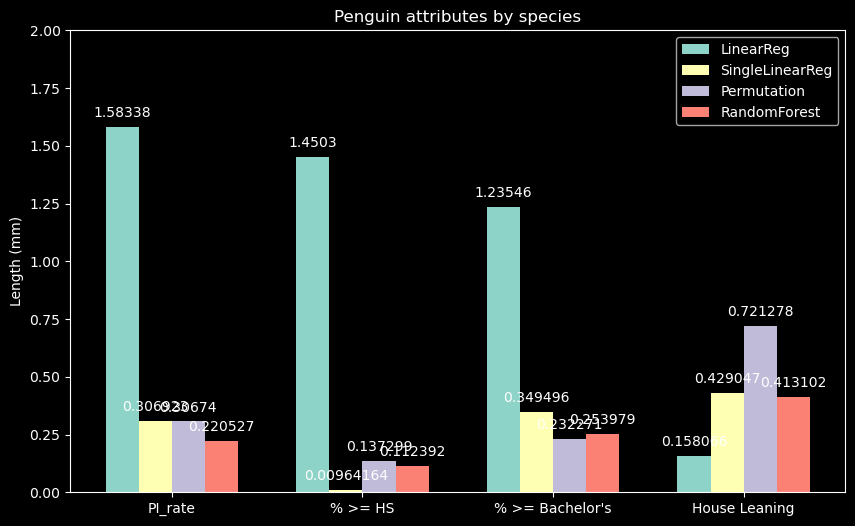

In [96]:
species = all_importance_scores2["Feature"]
penguin_means = all_importance_scores2[["LinearReg", "SingleLinearReg", "Permutation", "RandomForest"]]
x = np.arange(len(species))
width = 0.20        # slightly narrower bars
gap = 0.15          # extra space between groups
multiplier = 0

fig, ax = plt.subplots(figsize=(10, 6))

for attribute, measurement in penguin_means.items():
    offset = width * multiplier
    rects = ax.bar(x * (1 + gap) + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=5)
    multiplier += 1

n_bars = len(penguin_means.columns)
tick_positions = x * (1 + gap) + width * (n_bars - 1) / 2

ax.set_ylabel('Length (mm)')
ax.set_title('Penguin attributes by species')
ax.set_xticks(tick_positions, species)
ax.legend(loc='upper right', ncols=1)
ax.set_ylim(0, 2)
plt.show()